# Localization

A query image goes in and its camera pose in the reconstruction comes out, as a world-to-camera
matrix in the same frame as the keyframe poses, together with a refined focal length. The page
localizes two queries: a frame of the tutorial video, whose pose the reconstruction already knows,
and a frame from a different video of the same place.

In [1]:
import contextlib
import io

import numpy as np
import pyvista as pv
from scipy.spatial.distance import pdist
from scipy.spatial.transform import Rotation

from collab_splats.geometry.transforms import invert_poses
from collab_splats.localization import (
    CameraLocalizer,
    LocalMatcher,
    correspondences_for_ref,
    plot_correspondences,
    plot_inlier_distribution,
)
from collab_splats.pointcloud import PointcloudResult
from collab_splats.preproc import frames
from collab_splats.utils.io import read_image
from collab_splats.utils.visualization import (
    create_camera_frustum_pyvista,
    plot_reprojection,
    pointcloud_to_polydata,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud")

fps=2.000 wanted 199 frames, outside [min_frames=None, max_frames=96]; re-spread to 96 frames over the whole video (effective 0.964 fps)


## 1. The feature database

The localizer keeps one global DINO-SALAD descriptor and one set of LoMa keypoints and descriptors
per keyframe, plus the dense world points under every keyframe pixel.

In [2]:
# Dense per-pixel world points: the localizer lifts matched keyframe pixels through them
dense = PointcloudResult.load_zarr(
    scene.pointcloud_zarr, load_depth=False, load_confidence=False, load_pixel_indices=False
)

# Keyframes are named by their source frame index, in reconstruction order
frame_ids = []

for name in dense.image_paths:
    frame_ids.append(frames.frame_idx_from_path(name))

images = frames.read_frames(scene.images_dir, frame_ids)

# Extract and save the database into this page's work dir; torch.hub prints its cache path
matcher = LocalMatcher("loma")
features_zarr = work_dir("localization") / "features.zarr"
with contextlib.redirect_stderr(io.StringIO()):
    loc = CameraLocalizer.from_pointcloud(
        dense, zarr_path=features_zarr, images=images, extractor=matcher
    )

Indexing frames:   0%|          | 0/96 [00:00<?, ?frame/s]

## 2. A frame from the video

Localization runs in three steps. Global DINO-SALAD descriptors retrieve the keyframes that look
most like the query. LoMa matches local features between the query and each retrieved keyframe. PnP
with RANSAC then solves the pose from the query pixels and the 3D points under the matched keyframe
pixels. The query's intrinsics are seeded from its image size, and the solve refines the focal
length.

The first query is frame 0 of the tutorial video, 1080×1920 portrait like the keyframes.

In [3]:
ref_query = read_image(REF_FRAME)
ref_pose = loc.localize(ref_query)
print(f"{ref_pose.n_inliers} / {ref_pose.n_correspondences} correspondences are inliers")

3179 / 7070 correspondences are inliers


The reconstruction fitted its own pose for frame 0, so the two can be compared. Keyframes are named
by source frame index, which finds frame 0's row in the reconstruction. Frame selection keeps the
sharpest frame of each time slot, so frame 0 is a keyframe only when it wins its slot; the assert
stops the page if it did not.

The reconstruction has no metric scale, so the translation error is given as a fraction of the
largest distance between any two keyframe cameras.

In [4]:
# PnP must succeed, and source frame 0 must be a keyframe
assert ref_pose.pose is not None, "PnP failed on the in-video frame"
assert 0 in frame_ids, f"frame 0 is not a keyframe; keyframes start at {frame_ids[:3]}"

# Reconstruction row and fitted pose of source frame 0
row = frame_ids.index(0)
fitted = dense.extrinsics[row]

# Rotation error: angle of the rotation between the localized and fitted poses
fitted_inv = invert_poses(fitted)
relative = ref_pose.pose @ fitted_inv
rotation_error = np.degrees(Rotation.from_matrix(relative[:3, :3]).magnitude())

# Translation error: camera center offset over the trajectory extent
cam_to_world = invert_poses(dense.extrinsics)
centers = cam_to_world[:, :3, 3]
query_to_world = invert_poses(ref_pose.pose)
offset = query_to_world[:3, 3] - centers[row]
distance = np.linalg.norm(offset)
pair_distances = pdist(centers)
extent = pair_distances.max()

print(f"rotation error: {rotation_error:.2f} deg")
print(f"translation error: {distance / extent:.2%} of the trajectory extent")

rotation error: 0.05 deg
translation error: 0.04% of the trajectory extent


Both errors should be small. This is a consistency check rather than an accuracy test: the query is
an image the reconstruction already used, so it shows that matching and PnP agree with the fitted
pose, not how well an unseen view localizes.

## 3. A frame from another video

The second query is a 5312×2988 landscape frame from a different GoPro video of the same place.
Before matching, the localizer shrinks a query to the keyframes' long side, and the returned
intrinsics and pixels are mapped back to the full query size. There is no ground truth pose for this
frame, so everything below is a visual check only.

In [5]:
query = read_image(QUERY_IMAGE)
pose = loc.localize(query)
assert pose.pose is not None, "PnP failed on the cross-video frame"
print(f"{pose.n_inliers} / {pose.n_correspondences} correspondences are inliers")
print(f"refined focal length: {pose.query_intrinsics[0, 0]:.0f} px")

1444 / 4204 correspondences are inliers
refined focal length: 2829 px


The matches against the keyframe that contributed the most inliers.

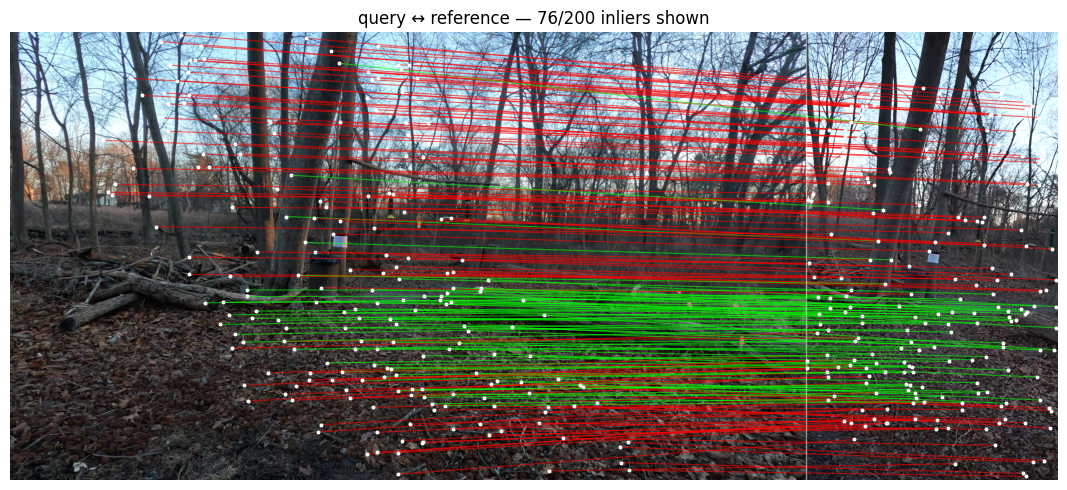

In [6]:
# Keyframe with the most inliers and its correspondences
best = pose.ranked_ref_frames[0]
ref_image = images[best]
query_px, ref_px, inliers = correspondences_for_ref(pose, best, ref_image.shape[:2])

fig = plot_correspondences(query, ref_image, query_px, ref_px, inlier_mask=inliers)

Green lines are RANSAC inliers and red lines outliers. Inliers spread across the image constrain the
pose better than a tight cluster.

Which keyframes the inliers came from:

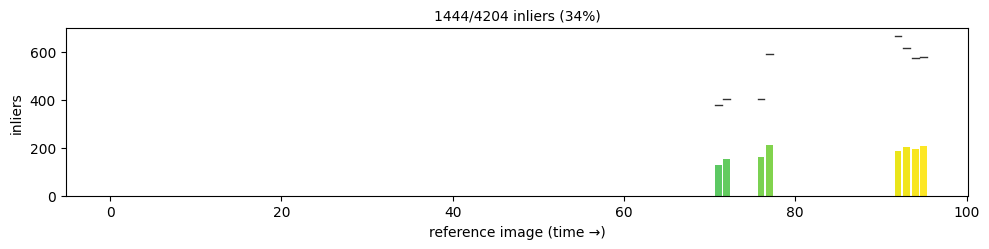

In [7]:
fig = plot_inlier_distribution(pose.ref_frame_indices, pose.inlier_mask, len(frame_ids))

Bars are keyframes in time order. Inliers should come from a few neighboring keyframes that view the
same part of the scene as the query. Black dashes mark each keyframe's total correspondences;
the bar is the part that survived RANSAC.

The pose in the scene, with keyframe cameras in grey and the query camera in red:

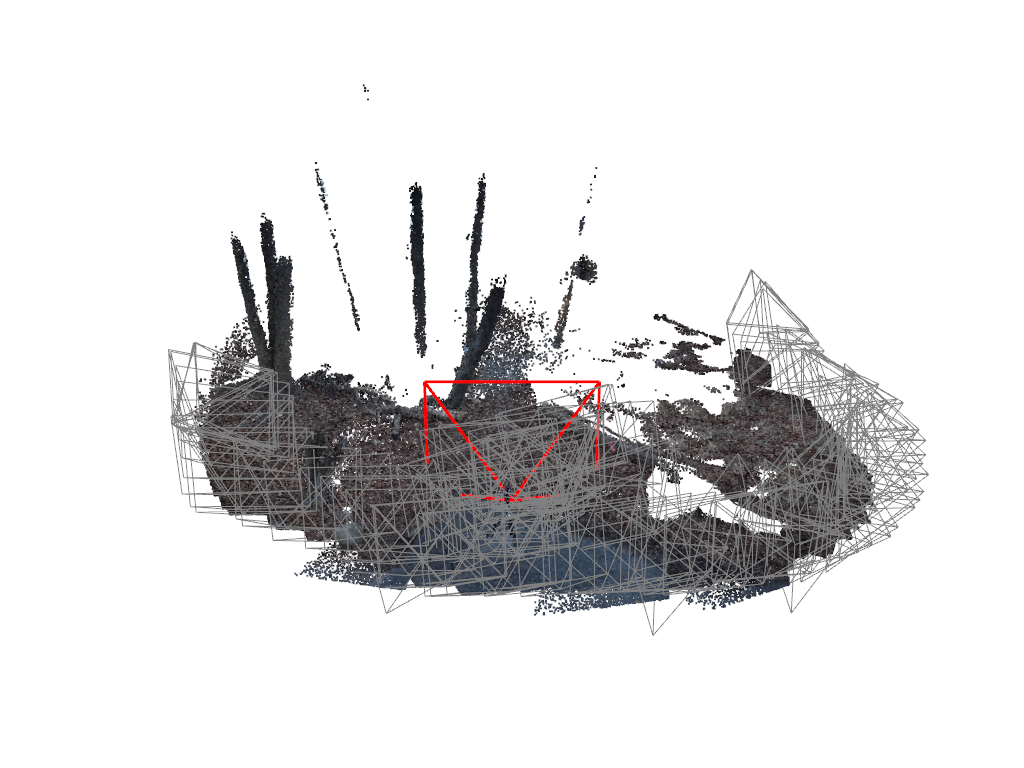

In [8]:
plotter = pv.Plotter()
cloud = pointcloud_to_polydata(dense.points, rgb=dense.colors)
plotter.add_mesh(cloud, scalars="rgb", rgb=True, point_size=2)

# Frustum sizes follow the trajectory extent; the reconstruction has no metric scale
frustum_scale = 0.02 * extent

# Keyframe cameras, then the localized query
for w2c in dense.extrinsics:
    frustum = create_camera_frustum_pyvista(w2c, scale=frustum_scale)
    plotter.add_mesh(frustum, color="grey")

query_scale = 1.5 * frustum_scale
query_frustum = create_camera_frustum_pyvista(pose.pose, scale=query_scale)
plotter.add_mesh(query_frustum, color="red", line_width=3)
# View from behind and above the query camera, looking past it into the scene
query_c2w = invert_poses(pose.pose)
query_center = query_c2w[:3, 3]
forward = query_c2w[:3, 2]
up = -query_c2w[:3, 1]
eye = query_center - 1.5 * extent * forward + 1.0 * extent * up
focus = query_center + 0.3 * extent * forward
plotter.camera_position = [eye, focus, up]
plotter.show()

The red camera should sit near the grey cameras that supplied its inliers and look at the same part
of the pointcloud.

The pointcloud rendered from the solved pose and refined focal length, next to the photo and blended
with it:

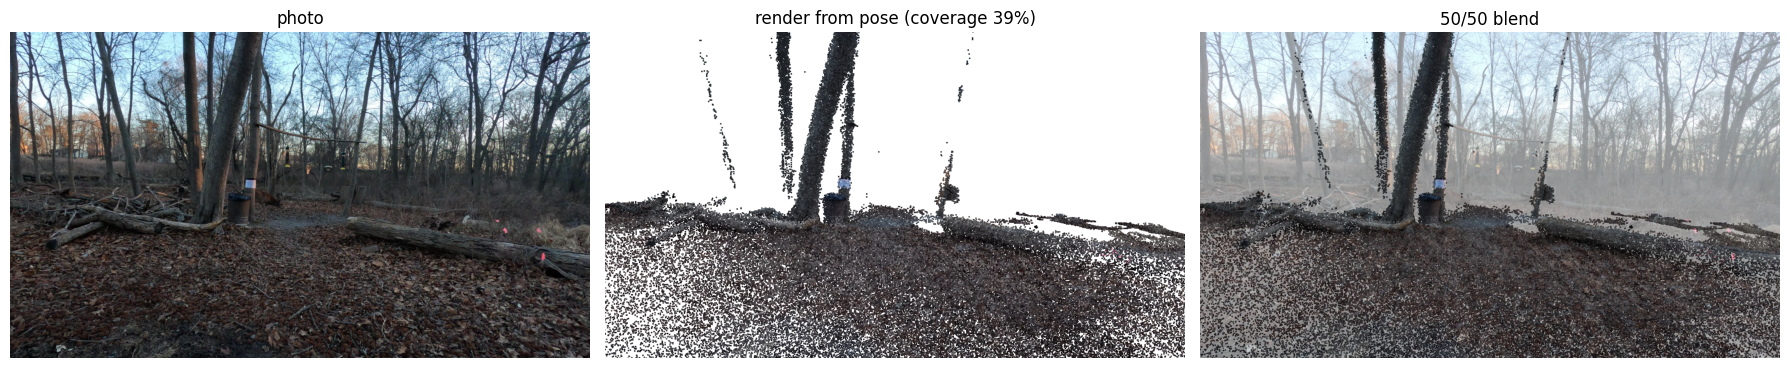

In [9]:
fig = plot_reprojection(query, dense.points, dense.colors, pose.pose, pose.query_intrinsics)

Where the pose is right, edges in the render line up with the same edges in the photo in the blend
panel.

## In a pipeline run

The `localize` stage builds the same feature database inside `pointcloud.zarr`, under
`local_features/<matcher>`. `matcher` takes `loma` or `xfeat` (lighter, fewer matches); the
localizer matches each query against features cached in the zarr, and only these two models can do
that. The `refine` stage rewrites `pointcloud.zarr` and drops the database, so run `localize` after
it.

```yaml
localization:
  enabled: true
  matcher: loma   # loma | xfeat
```